In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import shap
import pickle

print("All imported!")

All imported!


In [9]:
df = pd.read_csv(r'C:\Users\Admin\churn-prediction\data\cleaned_churn.csv')
print("Shape:", df.shape)
df.head(2)

Shape: (7043, 40)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,revenue_per_tenure
0,0,0,1,0,-1.277445,0,1,1,-1.160323,-0.994242,...,False,False,True,False,False,False,False,True,False,-0.757979
1,1,0,0,0,0.066327,1,0,0,-0.259629,-0.173244,...,False,False,False,True,False,False,False,False,True,-0.117801


In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 39)
Test size: (1409, 39)


In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression:")
print(classification_report(y_test, lr_pred))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, rf_pred))

Random Forest:
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1       0.68      0.51      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [13]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost:")
print(classification_report(y_test, xgb_pred))

XGBoost:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1036
           1       0.64      0.55      0.59       373

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [14]:
print("ROC AUC Scores:")
print("Logistic Regression:", round(roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]), 3))
print("Random Forest      :", round(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]), 3))
print("XGBoost            :", round(roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]), 3))

ROC AUC Scores:
Logistic Regression: 0.863
Random Forest      : 0.835
XGBoost            : 0.846


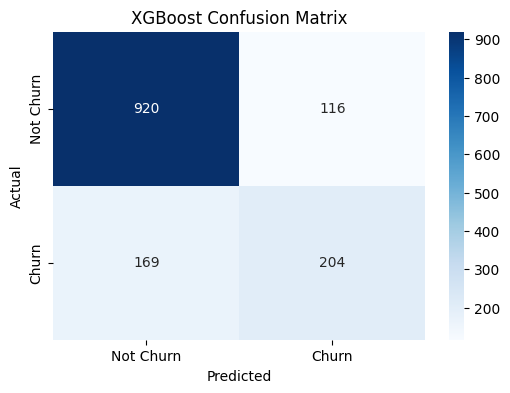

In [15]:
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not Churn','Churn'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

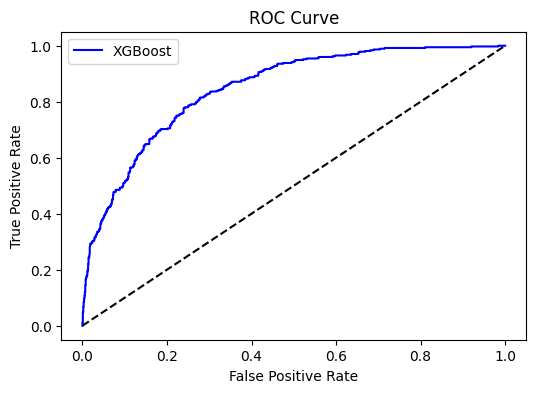

In [16]:
fpr, tpr, _ = roc_curve(y_test, xgb.predict_proba(X_test)[:,1])
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label='XGBoost')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

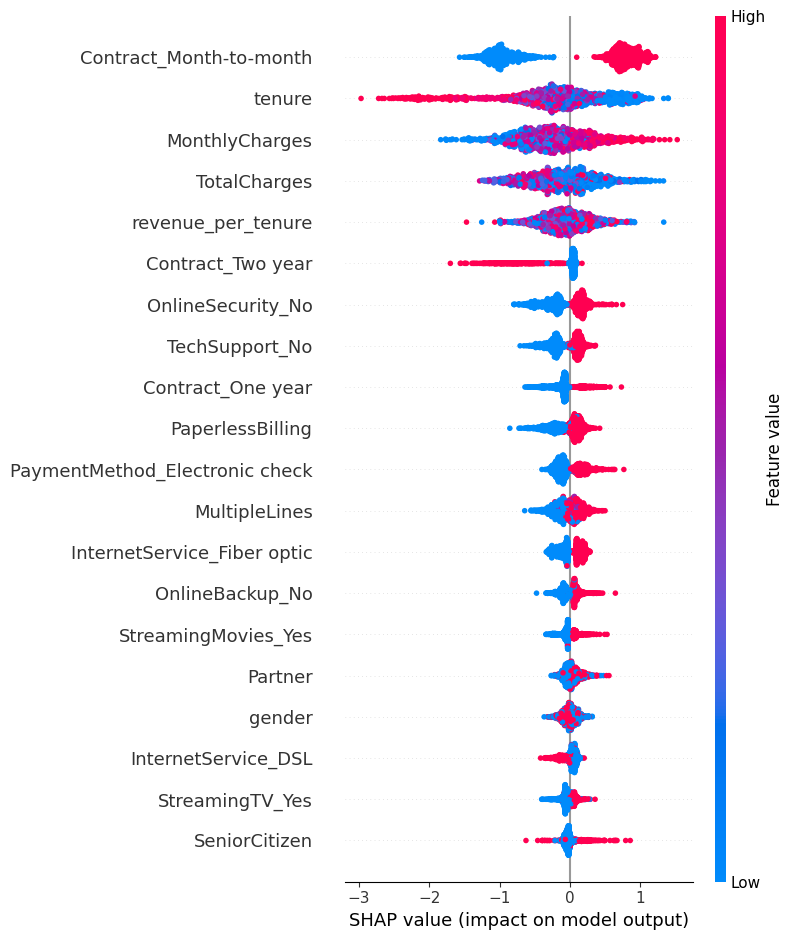

In [18]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [19]:
original_df = pd.read_csv(r'C:\Users\Admin\churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')
predicted_churn = xgb.predict(X_test)
churn_indices = X_test[predicted_churn == 1].index
revenue_at_risk = original_df.loc[churn_indices, 'MonthlyCharges'].sum()
print(f"Customers predicted to churn: {predicted_churn.sum()}")
print(f"Monthly Revenue at Risk: ${revenue_at_risk:,.2f}")

Customers predicted to churn: 320
Monthly Revenue at Risk: $24,556.80


In [17]:
pickle.dump(xgb, open(r'C:\Users\Admin\churn-prediction\models\xgb_model.pkl', 'wb'))
print("Model saved successfully!")

Model saved successfully!


In [20]:
pickle.dump(lr, open(r'C:\Users\Admin\churn-prediction\models\best_model.pkl', 'wb'))
print("Best model (Logistic Regression) saved!")

Best model (Logistic Regression) saved!


In [21]:
original_df = pd.read_csv(r'C:\Users\Admin\churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')
predicted_churn = lr.predict(X_test)
churn_indices = X_test[predicted_churn == 1].index
revenue_at_risk = original_df.loc[churn_indices, 'MonthlyCharges'].sum()
print(f"Customers predicted to churn: {predicted_churn.sum()}")
print(f"Monthly Revenue at Risk: ${revenue_at_risk:,.2f}")

Customers predicted to churn: 307
Monthly Revenue at Risk: $24,333.95


In [22]:
import pickle
# Save the exact column names the model was trained on
feature_names = list(X_train.columns)
pickle.dump(feature_names, open(r'C:\Users\Admin\churn-prediction\models\feature_names.pkl', 'wb'))
print("Feature names saved!")
print(f"Total features: {len(feature_names)}")
print(feature_names)

Feature names saved!
Total features: 39
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'revenue_per_tenure']
